<a href="https://colab.research.google.com/github/Vronska-Anhelina/University-app-/blob/main/predictive_model_for_student_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

import zipfile

zip_path = "/content/drive/MyDrive/university_schema.zip"
extract_path = "/content/university_schema"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)
path = extract_path
teachers = pd.read_csv(f"{path}/teachers.csv")
course_offerings = pd.read_csv(f"{path}/course_offerings.csv")
lessons = pd.read_csv(f"{path}/lessons.csv")
grades = pd.read_csv(f"{path}/grades.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
dataframe = grades.merge(course_offerings, on = "course_offering_id", how = "inner")
dataframe = dataframe.merge(teachers, on = "teacher_id", how = "inner")
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,group_id_y,teacher_id,semester_id,c,name,cathedra
0,1,1,71.4,2022-11-16,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
1,2,1,90.6,2022-09-10,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
2,3,1,66.5,2022-09-08,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
3,4,1,72.7,2022-10-16,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
4,5,1,70.0,2022-12-03,1,19,1,50,1,4,пан Андрій Гайворонський,Physics


In [73]:
dataframe = dataframe.drop("c", axis = 1)
dataframe = dataframe.drop("group_id_y", axis = 1)
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,teacher_id,semester_id,name,cathedra
0,1,1,71.4,2022-11-16,1,19,50,1,пан Андрій Гайворонський,Physics
1,2,1,90.6,2022-09-10,1,19,50,1,пан Андрій Гайворонський,Physics
2,3,1,66.5,2022-09-08,1,19,50,1,пан Андрій Гайворонський,Physics
3,4,1,72.7,2022-10-16,1,19,50,1,пан Андрій Гайворонський,Physics
4,5,1,70.0,2022-12-03,1,19,50,1,пан Андрій Гайворонський,Physics


In [74]:
lessons_count = lessons.groupby("course_offering_id").size().reset_index(name = "lessons_count")
dataframe = dataframe.merge(lessons_count, on = "course_offering_id")
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,teacher_id,semester_id,name,cathedra,lessons_count
0,1,1,71.4,2022-11-16,1,19,50,1,пан Андрій Гайворонський,Physics,14
1,2,1,90.6,2022-09-10,1,19,50,1,пан Андрій Гайворонський,Physics,14
2,3,1,66.5,2022-09-08,1,19,50,1,пан Андрій Гайворонський,Physics,14
3,4,1,72.7,2022-10-16,1,19,50,1,пан Андрій Гайворонський,Physics,14
4,5,1,70.0,2022-12-03,1,19,50,1,пан Андрій Гайворонський,Physics,14


In [75]:
dataframe = dataframe.sort_values(["student_id", "date"])
dataframe["student_avg_grade"] = (
    dataframe.groupby("student_id")["value"].mean())
dataframe["student_avg_grade"] = dataframe["student_avg_grade"].fillna(dataframe["value"].mean())
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,teacher_id,semester_id,name,cathedra,lessons_count,student_avg_grade
25,1,2,62.0,2022-09-07,1,7,11,1,Орися Піддубна,Computer Science,15,72.675000
0,1,1,71.4,2022-11-16,1,19,50,1,пан Андрій Гайворонський,Physics,14,74.932835
50,1,3,79.7,2022-11-17,1,15,50,1,пан Андрій Гайворонський,Physics,14,76.064516
75,1,4,63.3,2023-01-09,1,9,20,1,Віолетта Швачка,Economics,16,74.692308
8242,1,320,73.0,2023-03-22,1,17,57,2,пан Прохір Коваленко,Physics,14,74.932835


In [76]:
from sklearn.preprocessing import  LabelEncoder
from sklearn.model_selection import train_test_split

for col in ["teacher_id","course_id","group_id_x"]:
  dataframe[col] = LabelEncoder().fit_transform(dataframe[col])


feature = ["teacher_id","course_id","group_id_x", "semester_id","lessons_count", "student_avg_grade"]
X = dataframe[feature]
y = dataframe["value"]
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 50)

In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


LR = LinearRegression()
LR.fit(X_train, y_train)
LR_pred = LR.predict(X_test)


Random_forest = RandomForestRegressor(n_estimators = 100, random_state = 50)
Random_forest.fit(X_train,y_train)
Random_forest_pred = Random_forest.predict(X_test)

In [78]:
for name, pred in [("Linear Regression", LR_pred), ("Random Forest", Random_forest_pred)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name}: MAE = {mae}, RMSE = {rmse}")

Linear Regression: MAE = 10.187727776887225, RMSE = 12.600811307264824
Random Forest: MAE = 10.505549151003224, RMSE = 13.00777610622344


 Обидві моделі показують помірну точність прогнозу (середня помилка -10, 13 за RMSE), причому проста лінійна регресія працює не гірше за складніший Random Forest - отже, впроваджувати важчу модель економічно не є доцільним: простіше рішення однаково точне та легше пояснюється бізнесу.Остаточний висновок про придатність моделі для практичного використання можна зробити порівнявши цю помилку з допустимим для бізнесу порогом точності.В чому вимірюється й наскільки критична похибка 10-12 одиниць для цієї задачі.

 Похибка в 10-12 балів є суттєвою для більшості шкал оцінювання (наприклад, наша шкала в 0-100, це ±10-13%, що може змінити категорію та оцінку студента), тому модель у поточному вигляді підходить радше для орієнтовного/попереднього прогнозування чи виявлення студентів групи ризику(на межі відрахування), ніж для точного індивідуального оцінювання.

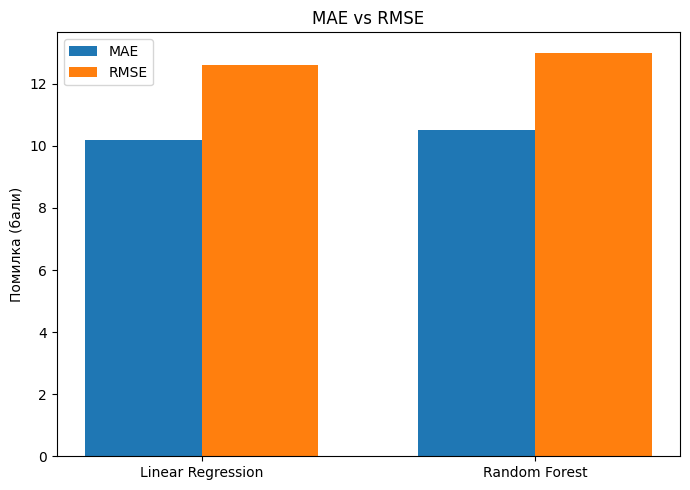

In [79]:
import matplotlib.pyplot as plt
models = ["Linear Regression", "Random Forest"]
mae_values = [10.187727776887225, 10.505549151003224]
rmse_values = [12.600811307264824, 13.00777610622344]
x = range(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(7,5))
ax.bar([i - width/2 for i in x], mae_values, width, label='MAE')
ax.bar([i + width/2 for i in x], rmse_values, width, label='RMSE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Помилка (бали)")
ax.set_title("MAE vs RMSE")
ax.legend()
plt.tight_layout()
plt.show()

Ускладнення моделі (Random Forest) не дає суттєвої переваги над простою лінійною регресією - обидві моделі однаковопрогнозують оцінки студентів із похибкою  приблизно в 10-13 балів.

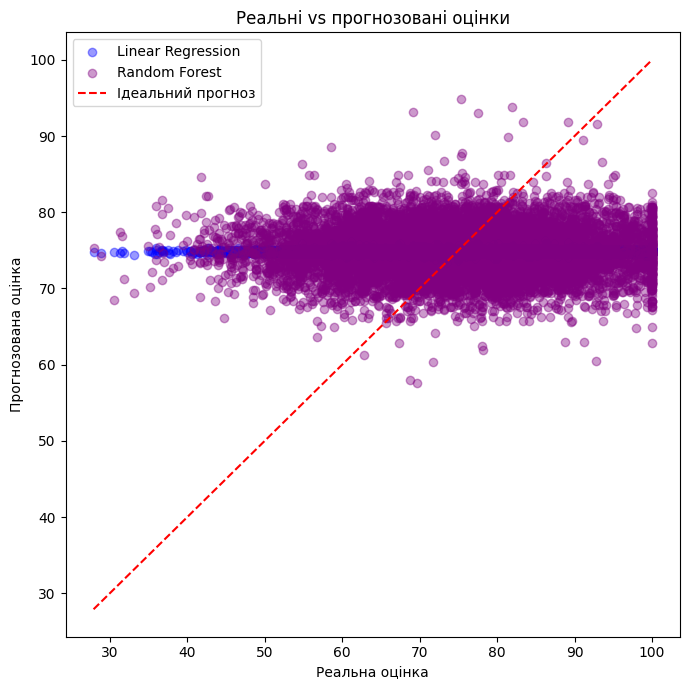

In [80]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, LR_pred, alpha=0.4, label="Linear Regression", color = "blue")
plt.scatter(y_test, Random_forest_pred, alpha=0.4, label="Random Forest", color = "purple")

min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ідеальний прогноз")

plt.xlabel("Реальна оцінка")
plt.ylabel("Прогнозована оцінка")
plt.title("Реальні vs прогнозовані оцінки")
plt.legend()
plt.tight_layout()
plt.show()

 Ця модель у поточному вигляді непридатна для практичного використання.Вона не відрізняє сильного студента від слабкого, а видає майже однаковий прогноз для всіх. Перш ніж покращувати алгоритм, потрібно переглянути набір ознак і перевірити, чи взагалі є в даних сигнал, який пояснює оцінку студента.

# ВИСНОВОК:
Проблема в тому, що наявний набір ознак не містить достатнього сигналу про індивідуальну підготовку студента. Модель у поточному вигляді непридатна для точного індивідуального прогнозування оцінок, хоча теоретично може використовуватись для дуже грубої, лише орієнтовної оцінки на рівні групи.

Для покращення точності варто додати ознаки, що прямо відображають індивідуальну поведінку та підготовку студента: відвідуваність занять, кількість спроб виконання завдань.Також, будуть корисними групові фактори (середня успішність і розмір групи). Без цих даних подальше вдосконалення алгоритмів не дасть суттєвий приріст якості прогнозу.